<a href="https://colab.research.google.com/github/safoolady23-wq/AIN-SA2-Part1/blob/main/AIN_SA2_Part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#import warnings
#warnings.filterwarnings('ignore')
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
#from sklearn.metrics import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

#df = pd.read_csv('Titanic-Dataset.csv') # Correct way to load a CSV file
train = pd.read_csv('Titanic-Dataset.csv')
test = pd.read_csv('Titanic-Dataset.csv')
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df = pd.concat([train, test], axis=0).reset_index(drop=True)
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,1782.000000,1782.000000,1782.000000,1428.000000,1782.000000,1782.000000,1782.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.281582,0.486456,0.835836,14.521407,1.102434,0.805831,49.679476
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.250000,0.000000,2.000000,20.000000,0.000000,0.000000,7.903100
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.750000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


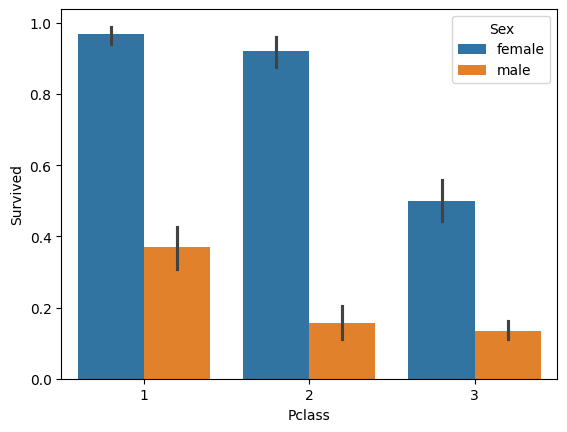

In [3]:
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df)
plt.show()

# this shows the which class has survivied more

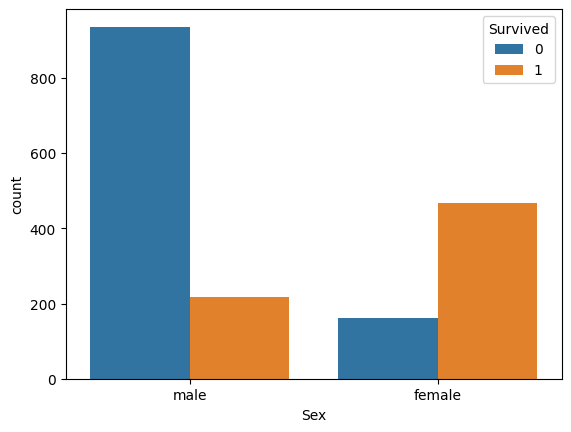

In [4]:
sns.countplot(x= 'Sex', hue= 'Survived', data=df)
plt.show()
# this section show that more fameles passengers survived than males passengers

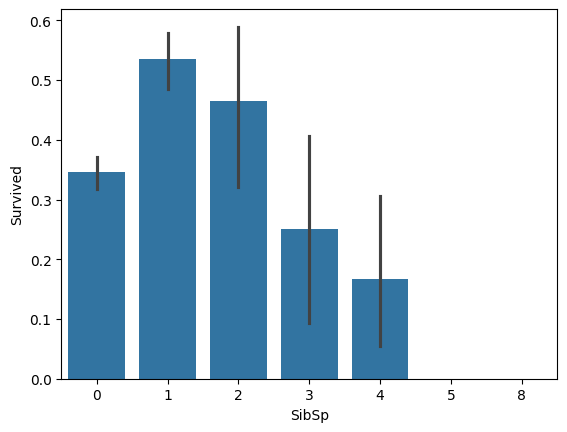

In [5]:
sns.barplot(x='SibSp', y='Survived', data=df)
plt.show()
#

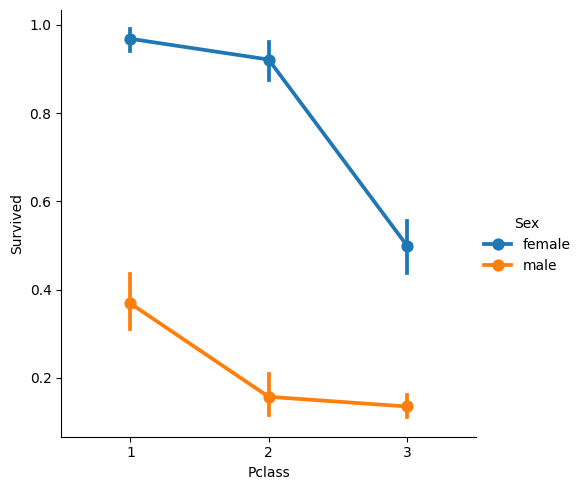

In [6]:
sns.catplot(x='Pclass', y='Survived', hue='Sex', data=df, kind='point')
plt.show()
# females in class 1 hava more chance of surviving than females in class 3

<Axes: xlabel='Age', ylabel='Fare'>

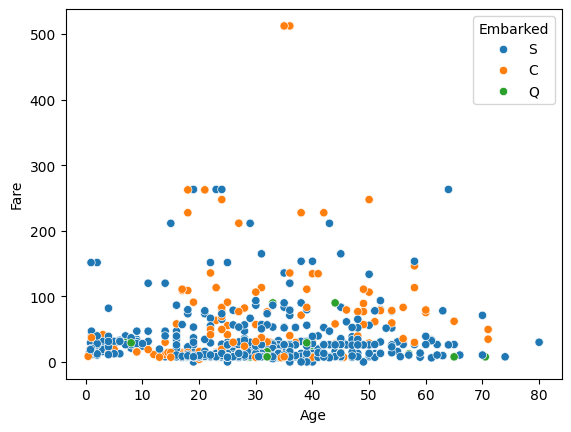

In [7]:
sns.scatterplot(x='Age', y='Fare', hue='Embarked',data=df)
# the graph shows the passengers age and how much they paied for thier fare and their place of embarketion.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1782 entries, 0 to 1781
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1782 non-null   int64  
 1   Survived     1782 non-null   int64  
 2   Pclass       1782 non-null   int64  
 3   Name         1782 non-null   object 
 4   Sex          1782 non-null   object 
 5   Age          1428 non-null   float64
 6   SibSp        1782 non-null   int64  
 7   Parch        1782 non-null   int64  
 8   Ticket       1782 non-null   object 
 9   Fare         1782 non-null   float64
 10  Cabin        408 non-null    object 
 11  Embarked     1778 non-null   object 
dtypes: float64(2), int64(5), object(5)
memory usage: 167.2+ KB


In [9]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1777,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
1778,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
1779,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
1780,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
1781,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


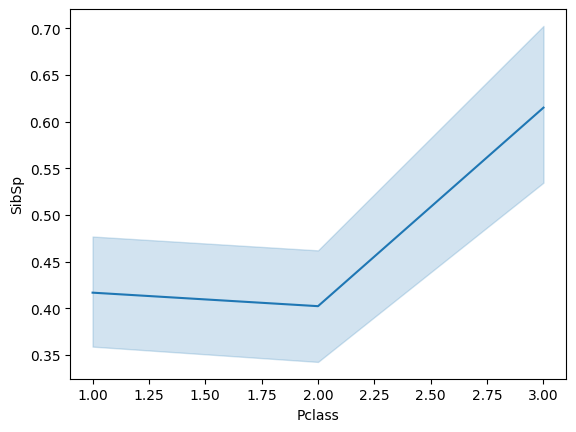

In [11]:
sns.lineplot(x='Pclass', y='SibSp', data=df)
plt.show()
#

In [12]:
df.isnull().sum()
#looking for a null value in the data, some of the data cannot have null value eg age and cabins.

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,354
SibSp,0
Parch,0
Ticket,0
Fare,0


In [13]:
#filling the missing value with mean columns
df['Age']= df['Age'].fillna(df['Age'].mean ())
#'].mean ())

In [19]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report # Import classification_report for later use

# Handle missing 'Embarked' values (if any remain)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Define features (X) and target (y)
# Drop irrelevant columns and the target variable itself
# Convert categorical features ('Sex', 'Embarked') using one-hot encoding
X = pd.get_dummies(df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin', 'Survived'], axis=1), drop_first=True)
y = df['Survived']

# predicting the accuracy of the data and checking for over-fitting
#https://www.kaggle.com/code/adeebmoizuddin/titanic-survival-prediction-using-machine-learning
# these two last section of the code have been used from the Github link above
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Accuracy
accuracy = model.score(X_test, y_test)
print("Accuracy =", accuracy)

# Predict on the test set to get y_pred for subsequent cells
y_pred = model.predict(X_test)

Accuracy = 0.8123249299719888


In [23]:
#printing the result of the prediction whit an accurecy of 81 percent.
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.8123249299719888
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       226
           1       0.74      0.75      0.75       131

    accuracy                           0.81       357
   macro avg       0.80      0.80      0.80       357
weighted avg       0.81      0.81      0.81       357

